<a href="https://colab.research.google.com/github/LucioFassarella/AMC/blob/main/Camila_perceptron_96.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
'''
Métodos auxiliares
'''

def binfloat(f, num_digitos = int):
    whole, dec = str(f).split(".")
    res = bin(int(whole))[2:] + "."

    dec = float("0." + dec)
    for _ in range(num_digitos):
        dec *= 2
        bit = int(dec)
        res += str(bit)
        dec -= bit
        if dec == 0: break

    #aproximação binária para resultado igual a 1
    if(res==1.0):
      res = 0.1111
    return res

import cv2
import numpy as np

def analyze_pixel_distribution(img_binary):
    """
    Analisa a distribuição de bits 1 (objeto) nas 4 metades da imagem.
    Assume que: Objeto = 1, Fundo = 0.
    Parâmetros:
      img_binary: imagem contendo 0 e 1.
    Retorna:
      features_images: dicionário contendo as features da imagem inteira.
      features_bbox: dicionário de bits contendo as features apenas dentro da
      delimitação da imagemm
    """
    # Garante que a imagem está em 1 único canal (escala de cinza/binária)
    if len(img_binary.shape) == 3:
        img_binary = cv2.cvtColor(img_binary, cv2.COLOR_BGR2GRAY)

    # Converte para uint8 para compatibilidade com cv2.threshold
    img_binary = img_binary.astype(np.uint8)

    # Garante que a imagem está estritamente binária com valores 0 e 1
    # (Se vier do OpenCV padrão onde branco é 255, isso converte para 1)
    _, img_bin = cv2.threshold(img_binary, 0, 1, cv2.THRESH_BINARY)

    height, width = img_bin.shape[:2]

    # -------------------------------------------------------------
    # ABORDAGEM 1: Contagem considerando a imagem INTEIRA
    # -------------------------------------------------------------
    # mid_y = height // 2
    # mid_x = width // 2

    # # Recorta as fatias da imagem e soma os bits 1
    # total_superior = np.sum(img_bin[0:mid_y, :])
    # total_inferior = np.sum(img_bin[mid_y:height, :])
    # total_esquerda = np.sum(img_bin[:, 0:mid_x])
    # total_direita  = np.sum(img_bin[:, mid_x:width])

    # -------------------------------------------------------------
    # ABORDAGEM 2: Contagem focada apenas na Bounding Box do número
    # (Evita que o posicionamento do número na tela altere o resultado)
    # -------------------------------------------------------------
    # Encontra onde estão os bits 1 (o número desenhado)
    pts = np.argwhere(img_bin == 1)

    if len(pts) == 0:
        # Imagem vazia (sem nenhum bit 1)
        bb_superior = bb_inferior = bb_esquerda = bb_direita = 0
    else:
        # Coordenadas da Bounding Box: [ymin, xmin] até [ymax, xmax]
        ymin, xmin = pts.min(axis=0)
        ymax, xmax = pts.max(axis=0)

        # Recorta apenas a região ocupada pelo número
        roi = img_bin[ymin:ymax+1, xmin:xmax+1]
        roi_h, roi_w = roi.shape

        # Define os meios da Bounding Box
        roi_mid_y = roi_h // 2
        roi_mid_x = roi_w // 2

        # Conta os bits 1 dentro das metades da Bounding Box
        bb_superior = np.sum(roi[0:roi_mid_y, :])
        bb_inferior = np.sum(roi[roi_mid_y:roi_h, :])
        bb_esquerda = np.sum(roi[:, 0:roi_mid_x])
        bb_direita  = np.sum(roi[:, roi_mid_x:roi_w])
    '''
    # Exibe os resultados
    print("=" * 50)
    print("      CONTAGEM DE BITS 1 (MÉTRICAS DA IMAGEM)")
    print("=" * 50)
    print(f"Dimensões da imagem: {width}x{height}")
    print("-" * 50)
    print("CONSIDERANDO A IMAGEM INTEIRA:")
    print(f"  • Metade Superior: {total_superior} bits")
    print(f"  • Metade Inferior: {total_inferior} bits")
    print(f"  • Metade Esquerda: {total_esquerda} bits")
    print(f"  • Metade Direita:  {total_direita} bits")
    print("-" * 50)
    print("CONSIDERANDO APENAS A BOUNDING BOX DO NÚMERO:")
    print(f"  • Metade Superior: {bb_superior} bits")
    print(f"  • Metade Inferior: {bb_inferior} bits")
    print(f"  • Metade Esquerda: {bb_esquerda} bits")
    print(f"  • Metade Direita:  {bb_direita} bits")
    print("=" * 50)
    '''
    # Retorna os dicionários
    # features_imagem = {"sup": total_superior, "inf": total_inferior,
    #                    "esq": total_esquerda, "dir": total_direita}
    features_bbox = {"sup": bb_superior, "inf": bb_inferior, "esq": bb_esquerda,
                     "dir": bb_direita}
    '''
    if(features_imagem["inf"]==0):
      Hr = features_imagem["sup"]/1.0
    else:
      Hr = features_imagem["sup"]/features_imagem["inf"]

    if(features_imagem["dir"]==0):
      Vr= features_imagem["esq"]/1.0
    else:
      Vr = features_imagem["esq"]/features_imagem["dir"]
    '''
    if(features_bbox["inf"]==0):
      Hr = features_bbox["sup"]/1.0
    else:
      Hr = features_bbox["sup"]/features_bbox["inf"]

    if(features_bbox["dir"]==0):
      Vr= features_bbox["esq"]/1.0
    else:
      Vr = features_bbox["esq"]/features_bbox["dir"]

    return Hr, Vr

import numpy as np

def importar_pbm_p1(caminho_arquivo):
    """
    Lê um arquivo PBM (formato P1 ASCII), ignorando comentários,
    e retorna uma matriz binária (NumPy array).
    """
    with open(caminho_arquivo, 'r', encoding='utf-8') as f:
        linhas = f.readlines()

    dados_uteis = []
    largura = 0
    altura = 0
    dimensoes_encontradas = False

    for linha in linhas:
        linha = linha.strip()

        # Ignora linhas vazias ou comentários
        if not linha or linha.startswith('#'):
            continue

        # Pula o cabeçalho 'P1' se ele existir no arquivo
        if linha == 'P1':
            continue

        # A primeira linha que não é comentário/P1 deve ser a dimensão (ex: "128 128")
        if not dimensoes_encontradas:
            partes = linha.split()
            largura = int(partes[0])
            altura = int(partes[1])
            dimensoes_encontradas = True
            continue

        # O que sobrar são os bits da imagem
        dados_uteis.append(linha)

    # Junta todas as linhas de bits em uma única string e remove espaços se houver
    string_bits = "".join(dados_uteis).replace(" ", "").replace("\n", "")

    # Converte a string de caracteres '0' e '1' em uma lista de inteiros
    lista_pixels = [int(bit) for bit in string_bits]

    # Transforma em uma matriz bidimensional (Numpy Array) com as dimensões corretas
    matriz_imagem = np.array(lista_pixels).reshape((altura, largura))

    return matriz_imagem

#Passo 1.1:Importando Dados Teste
def importar_pacote_imagens_pbm(caminho_pasta, numero_inicial, quantidade):
    """
    Importa uma sequência de arquivos .pbm numerados sequencialmente a partir de um diretório.

    Parâmetros:
    - caminho_pasta (str): Caminho do diretório onde as imagens estão (ex: "/content/.../8/")
    - numero_inicial (int): O número do primeiro arquivo a ser importado (ex: 850)
    - quantidade (int): Quantidade de imagens a serem importadas em sequência (padrão: 6)

    Retorna:
    - list: Lista contendo as matrizes das imagens importadas com sucesso.
    """

    import os

    if quantidade is None:
        quantidade = len(os.listdir('caminho_pasta'))

    lista_de_matrizes = []
    numero_atual = numero_inicial

    # Garante que o caminho da pasta termine com uma barra para não quebrar a string
    if not caminho_pasta.endswith('/'):
        caminho_pasta += '/'

    for i in range(quantidade):
        # Monta o caminho completo usando os parâmetros dinâmicos
        caminho_completo = f"{caminho_pasta}{numero_atual}.pbm"

        try:
            # Importa a matriz atual usando função importar_pbm_p1
            matriz_atual = importar_pbm_p1(caminho_completo)

            # Adiciona a matriz na lista de armazenamento
            lista_de_matrizes.append(matriz_atual)
            print(f"[{i+1}/{quantidade}] {caminho_completo} importado com sucesso!")

        except FileNotFoundError:
            print(f"Erro: O arquivo {caminho_completo} não foi encontrado. Interrompendo importação.")
            break  # Para o loop se um arquivo falhar

        # Incrementa para o próximo número de arquivo
        numero_atual += 1

    # --- Resumo pós-loop ---
    print("\n--- Resumo da Importação ---")
    if lista_de_matrizes:
        print(f"Total de {len(lista_de_matrizes)} imagens importadas com sucesso!")
        # Verifica se o objeto retornado possui o atributo shape (como matrizes NumPy)
        if hasattr(lista_de_matrizes[0], 'shape'):
            print(f"Formato de cada matriz: {lista_de_matrizes[0].shape}")
    else:
        print("Nenhuma imagem foi importada.")

    return lista_de_matrizes

#PASSO 2: Extraindo Hr, Vr
def extrair_caracteristicas_imagens(lista_de_matrizes, exibir=True):
    """
    Obtém as razões horizontais (Hr) e verticais (Vr) de uma lista de imagens binárias.

    Parâmetros:
    - lista_de_matrizes (list): Lista contendo as matrizes das imagens.
    - exibir (bool): Se True, imprime a lista formatada na tela.

    Retorna:
    - list: Lista de listas no formato [[Hr, Vr], [Hr, Vr], ...] com valores float.
    """
    lista_hr_vr = []

    # Passo 3: Processa cada imagem para obter Hr e Vr
    for matriz in lista_de_matrizes:
        Hr, Vr = analyze_pixel_distribution(matriz)
        lista_hr_vr.append([float(Hr), float(Vr)]) # Garante que os valores sejam float

    # Imprime os resultados se verbose for True
    if exibir:
        for i, valores in enumerate(lista_hr_vr):
            print(f"Lista_hr_vr[{i}]: {valores}")

    return lista_hr_vr

#PASSO 4: NORMALIZAR DADOS OBTIDOS NO PASSO ANTERIOR

def fator_normaliza(lista_hr_vr):
    """
    Calcula os fatores de normalização (maior valor de Hr e Vr)
    # Encontra o maior valor de Hr (índice 0) e Vr (índice 1)
    """
    max_hr = max(lista_hr_vr, key=lambda x: x[0])[0]
    max_vr = max(lista_hr_vr, key=lambda x: x[1])[1]

    return max_hr, max_vr

def normalizar_caracteristicas(lista_hr_vr, max_hr, max_vr, exibir=True):
    """
    Normaliza os valores de Hr e Vr dividindo-os pelo maior valor de cada coluna.
    Substitui o valor 1.0 por 0.1111 caso a normalização resulte em 1.

    Parâmetros:
    - lista_hr_vr (list): Lista de listas no formato [[Hr, Vr], ...]
    - exibir (bool): Se True, imprime a lista normalizada na tela.

    Retorna:
    - list: Nova lista com os valores devidamente normalizados.
    """

    lista_normalizada = []

    # Processa e normaliza cada par [Hr, Vr]
    i = 0
    for item in lista_hr_vr:
        i += 1
        item[0] = item[0] / max_hr
        item[1] = item[1] / max_vr

        # Aplica a sua regra de corte para evitar o valor 1.0
        '''
        if hr_norm == 1.0:
            hr_norm = 0.1111

        if vr_norm == 1.0:
            vr_norm = 0.1111
        '''

        # Adiciona os valores transformados à nova lista
        lista_normalizada.append([item[0], item[1]])

        if exibir:
            print(f"Lista_hr_vr[{i}]: [{item[0]}, {item[1]}]")

    return lista_normalizada

#PASSO 5: TRANSFORMAR DADOS PARA VALORES BINÁRIOS

def converter_recursos_para_binario(lista_hr_vr, num_digitos=7, exibir=True):
    """
    Converte os valores float (Hr e Vr) de uma lista para suas representações binárias
    utilizando a função binfloat().

    Parâmetros:
    - lista_hr_vr (list): Lista de listas no formato [[Hr, Vr], ...] com valores float.
    - num_digitos (int): Quantidade de dígitos/bits para a conversão (padrão: 8).
    - exibir (bool): Se True, imprime a lista convertida na tela.

    Retorna:
    - list: Nova lista contendo os valores convertidos em binário pela função binfloat.
    """
    lista_binaria = []

    # Passo 5: Aplica a função binfloat em cada valor de Hr e Vr
    for i, par in enumerate(lista_hr_vr):
        hr_bin = binfloat(par[0], num_digitos=num_digitos)
        vr_bin = binfloat(par[1], num_digitos=num_digitos)

        # Adiciona o par convertido à nova lista
        lista_binaria.append([hr_bin, vr_bin])

        if exibir:
            print(f"Lista_hr_vr4[{i}]: [{hr_bin}, {vr_bin}]")

    return lista_binaria

#Paso 6.1: ORGANIZANDO DADOS
def mesclar_recursos_binarios(lista_hr_vr_binaria, exibir=True):
    """
    Mescla (concatena) os componentes binários Hr e Vr de cada imagem em uma única string.

    Parâmetros:
    - lista_hr_vr_binaria (list): Lista de listas no formato [[hr_bin, vr_bin], ...]
    - verbose (bool): Se True, imprime a lista mesclada na tela.

    Retorna:
    - list: Nova lista contendo as strings binárias mescladas (ex: ['01011100', ...]).
    """
    lista_mesclada = []

    # Passo 6.1: Mesclar Hr e Vr em um elemento só
    for i, par in enumerate(lista_hr_vr_binaria):
        # Concatena a string do Hr com a string do Vr
        recurso_mesclado = par[0] + par[1]
        lista_mesclada.append(recurso_mesclado)

        if exibir:
            print(f"ListaHrVr4[{i}]: {recurso_mesclado}")

    return lista_mesclada

#PASSO 6.2: ORGANIZANDO DADOS:
def transformar_para_vetor_bits(lista_hr_vr_binaria, exibir=True):
    """
    Transforma os elementos em strings, remove apenas os pontos decimais
    e converte absolutamente todos os dígitos (incluindo os zeros) em um vetor de inteiros.
    """
    lista_vetores_finais = []

    for i, elemento in enumerate(lista_hr_vr_binaria):
        # 1. Se o elemento for uma lista/tupla (ex: ['0.111.100']), junta em uma string só
        if isinstance(elemento, (list, tuple)):
            texto_puro = "".join(str(x) for x in elemento)
        else:
            texto_puro = str(elemento)

        # 2. Remove APENAS o caractere de ponto decimal
        string_sem_pontos = texto_puro.replace(".", "")

        # 3. Transforma cada caractere numérico em um número inteiro, mantendo todos os zeros
        vetor_bits = [int(bit) for bit in string_sem_pontos if bit.isdigit()]

        # 4. Guarda o vetor na lista final
        lista_vetores_finais.append(vetor_bits)

        if exibir:
            print(f"ListaHrVr[{i}]: {vetor_bits}")

    return lista_vetores_finais

#PASSO 7: CLASSIFICANDO DADOS
def adicionar_exemplos_ao_dataset(lista_vetores, classe, lista_dados_existente=None, exibir=True):
    """
    Adiciona os vetores de bits e suas respectivas classificações (labels)
    a uma lista unificada de dados.

    Parâmetros:
    - lista_vetores (list): Lista de vetores de bits (saída do Passo 6.2).
    - classe (int): O rótulo da classe (ex: 0 para o caractere 4, 1 para o caractere 8).
    - lista_dados_existente (list): Uma lista existente para acumular os dados. Se None, cria uma nova.
    - exibir (bool): Se True, imprime a lista de dados na tela.

    Retorna:
    - list: Lista atualizada contendo pares no formato [vetor_bits, classe].
    """
    # Se não for passada uma lista existente, inicializa uma nova vazia
    if lista_dados_existente is None:
        lista_dados_existente = []

    # Armazena o índice inicial para o print correto no modo verbose
    indice_inicial = len(lista_dados_existente)

    # Passo 7: Adiciona cada vetor com sua respectiva classificação
    for vetor in lista_vetores:
        lista_dados_existente.append([vetor, classe])

    if exibir:
        for i in range(indice_inicial, len(lista_dados_existente)):
            print(f"ListaDados[{i}]: {lista_dados_existente[i]}")

    return lista_dados_existente

In [3]:
'''
Montagem de drive
'''

from google.colab import drive
drive.mount('/content/drive')

# Conteúdo

import os

print("Conteúdo de '/content/drive/MyDrive/Colab Notebooks/OCR':")
print(os.listdir('/content/drive/MyDrive/Colab Notebooks/OCR/6'))

Mounted at /content/drive
Conteúdo de '/content/drive/MyDrive/Colab Notebooks/OCR':
['828.pbm', '840.pbm', '883.pbm', '869.pbm', '829.pbm', '877.pbm', '872.pbm', '860.pbm', '865.pbm', '825.pbm', '885.pbm', '817.pbm', '826.pbm', '815.pbm', '803.pbm', '802.pbm', '820.pbm', '843.pbm', '876.pbm', '868.pbm', '809.pbm', '892.pbm', '810.pbm', '832.pbm', '848.pbm', '882.pbm', '870.pbm', '827.pbm', '861.pbm', '837.pbm', '889.pbm', '846.pbm', '842.pbm', '887.pbm', '859.pbm', '806.pbm', '867.pbm', '880.pbm', '800.pbm', '804.pbm', '896.pbm', '881.pbm', '874.pbm', '855.pbm', '856.pbm', '852.pbm', '847.pbm', '812.pbm', '833.pbm', '866.pbm', '854.pbm', '862.pbm', '822.pbm', '834.pbm', '823.pbm', '853.pbm', '878.pbm', '845.pbm', '891.pbm', '857.pbm', '875.pbm', '863.pbm', '893.pbm', '850.pbm', '897.pbm', '831.pbm', '816.pbm', '890.pbm', '805.pbm', '801.pbm', '884.pbm', '894.pbm', '841.pbm', '858.pbm', '839.pbm', '836.pbm', '838.pbm', '821.pbm', '808.pbm', '814.pbm', '871.pbm', '835.pbm', '864.pbm', '8

In [24]:
'''
LISTA 6
'''

#Passo 1: Importando imagens
# Definindo as configurações
pasta_treino_6 = "/content/drive/MyDrive/Colab Notebooks/OCR/6/"

# Chamando a função
matrizes_treino_6 = importar_pacote_imagens_pbm(
    caminho_pasta=pasta_treino_6,
    numero_inicial=600,
    quantidade=100
)
###############################################

'''
PASSO  3:
    PARA CADA IMAGEM DE NÚMERO IRÁ SER OBTIDA O VALOR Hr (M. ESQ/ M. DIR) E Vr (M.SUP/M.INF) pela função analyze_pixel_distribution(img_binary)
    Colocado esses valores em uma lista L = [[Hr,Vr],[Hr,Vr],[Hr,Vr],...] float
'''
lista_6_treino = extrair_caracteristicas_imagens(matrizes_treino_6, exibir=True)

del lista_6_treino[21]


lista_6 = lista_6_treino.copy()

display(lista_6)

print(len(lista_6_treino))

[1/100] /content/drive/MyDrive/Colab Notebooks/OCR/6/600.pbm importado com sucesso!
[2/100] /content/drive/MyDrive/Colab Notebooks/OCR/6/601.pbm importado com sucesso!
[3/100] /content/drive/MyDrive/Colab Notebooks/OCR/6/602.pbm importado com sucesso!
[4/100] /content/drive/MyDrive/Colab Notebooks/OCR/6/603.pbm importado com sucesso!
[5/100] /content/drive/MyDrive/Colab Notebooks/OCR/6/604.pbm importado com sucesso!
[6/100] /content/drive/MyDrive/Colab Notebooks/OCR/6/605.pbm importado com sucesso!
[7/100] /content/drive/MyDrive/Colab Notebooks/OCR/6/606.pbm importado com sucesso!
[8/100] /content/drive/MyDrive/Colab Notebooks/OCR/6/607.pbm importado com sucesso!
[9/100] /content/drive/MyDrive/Colab Notebooks/OCR/6/608.pbm importado com sucesso!
[10/100] /content/drive/MyDrive/Colab Notebooks/OCR/6/609.pbm importado com sucesso!
[11/100] /content/drive/MyDrive/Colab Notebooks/OCR/6/610.pbm importado com sucesso!
[12/100] /content/drive/MyDrive/Colab Notebooks/OCR/6/611.pbm importado co

[[0.3132716049382716, 1.2277486910994764],
 [0.38839285714285715, 1.0733333333333333],
 [0.49382716049382713, 1.388157894736842],
 [0.47010309278350515, 1.2006172839506173],
 [0.45962732919254656, 1.079646017699115],
 [0.38571428571428573, 1.7626582278481013],
 [0.4165103189493433, 0.9509043927648578],
 [0.5486725663716814, 1.0068807339449541],
 [0.4552380952380952, 1.0482573726541555],
 [0.3483483483483483, 1.4875346260387812],
 [0.32195121951219513, 1.2489626556016598],
 [0.354656632173095, 0.7910447761194029],
 [0.42857142857142855, 1.065217391304348],
 [0.3881856540084388, 1.05625],
 [0.6099173553719008, 0.7117750439367311],
 [0.47875816993464054, 1.0662100456621004],
 [0.48997772828507796, 1.1650485436893203],
 [0.3283208020050125, 1.314410480349345],
 [0.3470790378006873, 1.6133333333333333],
 [0.5148514851485149, 1.0675675675675675],
 [0.36675461741424803, 0.7923875432525952],
 [0.4929906542056075, 1.0746753246753247],
 [0.4188034188034188, 1.0815047021943573],
 [0.3327974276527

99


In [26]:
'''
LISTA 9
'''

#Passo 1: Importando imagens
# Definindo as configurações
pasta_treino_9 = "/content/drive/MyDrive/Colab Notebooks/OCR/9/"

# Chamando a função
matrizes_treino_9 = importar_pacote_imagens_pbm(
    caminho_pasta=pasta_treino_9,
    numero_inicial=900,
    quantidade=100
)
###############################################

'''
PASSO  3:
    PARA CADA IMAGEM DE NÚMERO IRÁ SER OBTIDA O VALOR Hr (M. ESQ/ M. DIR) E Vr (M.SUP/M.INF) pela função analyze_pixel_distribution(img_binary)
    Colocado esses valores em uma lista L = [[Hr,Vr],[Hr,Vr],[Hr,Vr],...] float
'''
lista_9_treino = extrair_caracteristicas_imagens(matrizes_treino_9, exibir=True)

#del lista_4_treino[21]


lista_9 = lista_9_treino.copy()

display(lista_9)

print(len(lista_9_treino))

[1/100] /content/drive/MyDrive/Colab Notebooks/OCR/9/900.pbm importado com sucesso!
[2/100] /content/drive/MyDrive/Colab Notebooks/OCR/9/901.pbm importado com sucesso!
[3/100] /content/drive/MyDrive/Colab Notebooks/OCR/9/902.pbm importado com sucesso!
[4/100] /content/drive/MyDrive/Colab Notebooks/OCR/9/903.pbm importado com sucesso!
[5/100] /content/drive/MyDrive/Colab Notebooks/OCR/9/904.pbm importado com sucesso!
[6/100] /content/drive/MyDrive/Colab Notebooks/OCR/9/905.pbm importado com sucesso!
[7/100] /content/drive/MyDrive/Colab Notebooks/OCR/9/906.pbm importado com sucesso!
[8/100] /content/drive/MyDrive/Colab Notebooks/OCR/9/907.pbm importado com sucesso!
[9/100] /content/drive/MyDrive/Colab Notebooks/OCR/9/908.pbm importado com sucesso!
[10/100] /content/drive/MyDrive/Colab Notebooks/OCR/9/909.pbm importado com sucesso!
[11/100] /content/drive/MyDrive/Colab Notebooks/OCR/9/910.pbm importado com sucesso!
[12/100] /content/drive/MyDrive/Colab Notebooks/OCR/9/911.pbm importado co

[[2.0968992248062017, 0.779510022271715],
 [2.476470588235294, 0.7331378299120235],
 [2.0, 1.1929824561403508],
 [2.4444444444444446, 1.1592039800995024],
 [2.1169590643274856, 1.337719298245614],
 [2.1243523316062176, 0.5382653061224489],
 [2.0672268907563027, 0.9466666666666667],
 [2.3482587064676617, 1.2813559322033898],
 [2.2337662337662336, 0.9402597402597402],
 [1.8783269961977187, 0.9713541666666666],
 [1.4054669703872438, 0.6171516079632465],
 [2.0869565217391304, 1.0579710144927537],
 [1.9891304347826086, 0.9713261648745519],
 [2.5307692307692307, 0.8850102669404517],
 [2.3006134969325154, 0.8680555555555556],
 [2.9404255319148938, 0.9956896551724138],
 [1.8126984126984127, 1.467966573816156],
 [2.7027027027027026, 0.8327759197324415],
 [1.951219512195122, 1.0302013422818792],
 [3.0327868852459017, 0.7202797202797203],
 [1.6633165829145728, 1.0463320463320462],
 [2.1853932584269664, 1.0469314079422383],
 [2.5611510791366907, 1.0454545454545454],
 [2.3012048192771086, 1.0679245

100


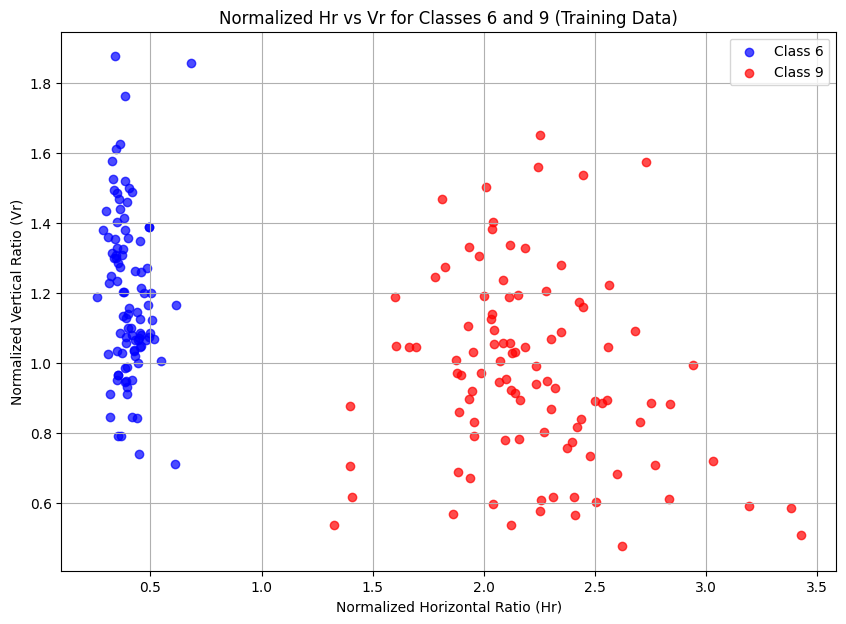

In [28]:
import matplotlib.pyplot as plt

# Extract Hr and Vr for class 8
hr_6 = [item[0] for item in lista_6]
vr_6 = [item[1] for item in lista_6]

# Extract Hr and Vr for class 4
hr_9 = [item[0] for item in lista_9]
vr_9 = [item[1] for item in lista_9]

plt.figure(figsize=(10, 7))
#plt.axis('scaled')

# Plotting class 8
plt.scatter(hr_6, vr_6, color='blue', label='Class 6', alpha=0.7)

# Plotting class 4
plt.scatter(hr_9, vr_9, color='red', label='Class 9', alpha=0.7)

plt.title('Normalized Hr vs Vr for Classes 6 and 9 (Training Data)')
plt.xlabel('Normalized Horizontal Ratio (Hr)')
plt.ylabel('Normalized Vertical Ratio (Vr)')
plt.legend()
plt.grid(True)
plt.show()